# AI-Powered Ultrasound Image Analysis with Hugging Face


# Object Detection in Medical Imaging - Code-Along Tutorial

## 🎯 Learning Objectives
By the end of this tutorial, you will:

- Learn how to use Hugging Face tools for image analysis
- Understand how to apply AI to ultrasound and other medical image data
- Explore a real-world use case focused on improving fetal health outcomes through AI analysis




## 📋 Prerequisites

- Basic Python programming knowledge
- Familiarity with machine learning concepts
- Understanding of image data (helpful but not required)

# Setup Instructions

## Environment Setup

In [1]:
# Install required packages
!pip install transformers torch torchvision pillow opencv-python matplotlib seaborn
!pip install datasets huggingface_hub accelerate

# Import essential libraries
import torch
import torchvision
import torchvision.transforms.functional as F
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from torch.utils.data import Dataset, dataloader
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import json
import os
import random
import cv2
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
# plt.rcParams['figure.figsize'] = (12, 8)

  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ------------------------- -------------- 6.8/10.8 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 10.8/10.8 MB 29.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 28.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/216.0 MB ? eta -:--:--
   - -------------------------------------- 6.6/216.0 MB 31.0 MB/s eta 0:00:07
   -- ------------------------------------- 13.1/216.0 MB 29.4 MB/s eta 0:00:07
   --- ------------------------------------ 20.7/216.0 MB 31.9 MB/s eta 0:00:07
   ----- ---------------------------------- 27.5/216.0 MB 31.7 MB/s eta 0:00:06
   ------ --------------------------------- 34.1/216.0 MB 31.8 MB/s eta 0:00:06
   ------- -----------------

c:\Users\Tanya Akumu\Documents\UB\PhD\datacamp-tutorial\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


## Dataset Overview

In [ ]:
# Download sample ultrasound images from the dataset provided
# Note: In practice, you would download from https://zenodo.org/records/7540448
# For this tutorial, we will simulate with sample data structure

print("🏥 Medical Ultrasound Dataset Overview")
print("=" * 50)
print("📊 Dataset: Fetal Ultrasound Scan Images fro Algeria")
print("🎯 Task: Detect Fetal anatomical structures from fetal ultrasound scans")
print("🎯 Structures to detect: Head, Femur, Abdomen, Heart")
print("📈 Applications: Fetal biometry (gestation age, abdominal circumference), growth assessment, anomaly detection")

# Understanding Medical Image Analysis


## Why Object detection in Medical Imaging Matters

AI is integrated into the healhcare delivery process by assisting clinicians like radiologists to conduct examinations much faster. In a typical medical imaging exam, the radiologist has to manually detect structures present in the image being scanned which ends up being time consuming, both for the patieint and the clinician. AI can reduce this time by automating this detection process and provide real time insights on measuremnts that can assist in quick and accurate diagnosis. The AI model will leatn to autmatically locate and classify the structures present in the image.

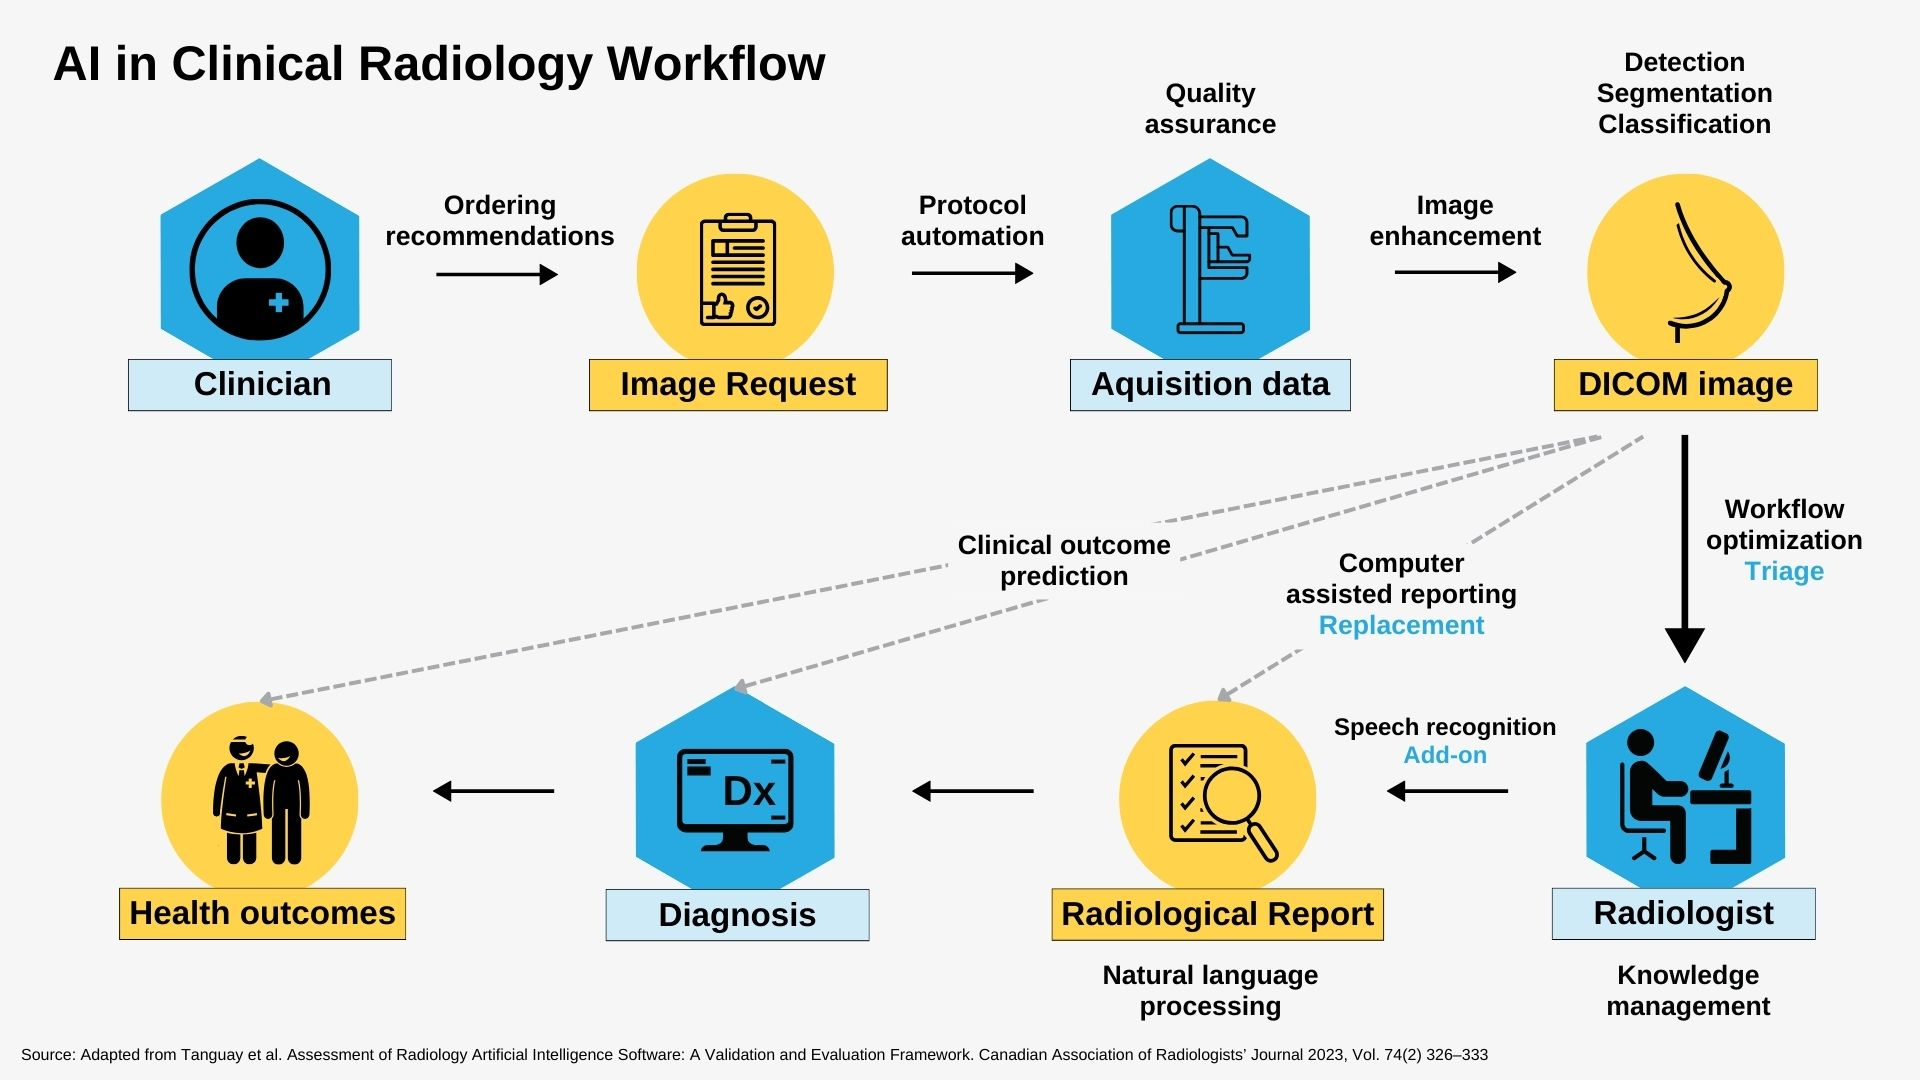


## AI for Low-resource Settings
This is especially important for low-resource settings (LRS). These are contexts where thy lack fundamental aspects like clinical expertise or medical imaging devices necessary to conduct quality healthcare examinations. AI can be used in these setttings to empower minimally trained workers to use low-cost devices and provide expert-level care to patients.

## Fetal Ultrasound

Fetal ultrasound is the gold standard for monitoring fetal developmeny ans ensuring timely clinical interventtions are applied in anenatal care. Variables such as gestational age, fetal growth restriction and maternal risk assesment (pre-eclampsia, placenta previa) are accessed through quality fetal ultrasound scans. This involves detecting key fetal anatomical structures that can tell us how well the baby is developing and if the mother is at risk. These include:

In [ ]:
# Define the structures we'll be detecting
ULTRASOUND_STRUCTURES = {
    'head': {
        'description': 'Fetal head circumference - crucial for gestational age estimation',
        'clinical_importance': 'Growth assessment, brain development monitoring',
        'measurement': 'Head circumference (HC)'
    },
    'abdomen': {
        'description': 'Fetal abdominal circumference - indicates overall growth',
        'clinical_importance': 'Nutritional status, growth restriction detection',
        'measurement': 'Abdominal circumference (AC)'
    },
    'femur': {
        'description': 'Fetal femur length - longest bone measurement',
        'clinical_importance': 'Skeletal development, gestational age estimation',
        'measurement': 'Femur length (FL)'
    },
    'heart': {
        'description': 'Fetal heart structure and function',
        'clinical_importance': 'Cardiac anomaly detection, rhythm assessment',
        'measurement': 'Heart rate, chamber dimensions'
    }
}

# Display structure information
for structure, info in ULTRASOUND_STRUCTURES.items():
    print(f"🫀 {structure.upper()}")
    print(f"   📝 {info['description']}")
    print(f"   🎯 {info['clinical_importance']}")
    print(f"   📏 {info['measurement']}")
    print()

🫀 HEAD
   📝 Fetal head circumference - crucial for gestational age estimation
   🎯 Growth assessment, brain development monitoring
   📏 Head circumference (HC)

🫀 ABDOMEN
   📝 Fetal abdominal circumference - indicates overall growth
   🎯 Nutritional status, growth restriction detection
   📏 Abdominal circumference (AC)

🫀 FEMUR
   📝 Fetal femur length - longest bone measurement
   🎯 Skeletal development, gestational age estimation
   📏 Femur length (FL)

🫀 HEART
   📝 Fetal heart structure and function
   🎯 Cardiac anomaly detection, rhythm assessment
   📏 Heart rate, chamber dimensions



# Introduction to Hugging Face for Computer Vision

Hugging face is a platform that helps users build, deploy and train AI models. The AI community collaborates on sharing pretrained models that users can adapt to their own custom datasets with minimal code. Users have access to cutting-edge research and models, deploy this models with minimal infrastructure and obtain the latest advances in computer vison through continuous updates

In [ ]:
# Let's explore object detection models suitable for medical imaging
from transformers import AutoConfig
# more back ground context
# Popular object detection architectures
DETECTION_MODELS = {
    'DETR': 'facebook/detr-resnet-50',
    'YOLOS': 'hustvl/yolos-tiny',
    'Conditional DETR': 'microsoft/conditional-detr-resnet-50'
}

print("🔍 Object Detection Models Available:")
print("=" * 40)

for name, model_id in DETECTION_MODELS.items():
    try:
        config = AutoConfig.from_pretrained(model_id)
        print(f"✅ {name}: {model_id}")
        print(f"   Architecture: {config.model_type}")
        print(f"   Suitable for: General object detection (can be fine-tuned)")
        print()
    except Exception as e:
        print(f"❌ Could not load {name}: {str(e)}")

🔍 Object Detection Models Available:


config.json: 0.00B [00:00, ?B/s]

✅ DETR: facebook/detr-resnet-50
   Architecture: detr
   Suitable for: General object detection (can be fine-tuned)



config.json: 0.00B [00:00, ?B/s]

✅ YOLOS: hustvl/yolos-tiny
   Architecture: yolos
   Suitable for: General object detection (can be fine-tuned)



config.json: 0.00B [00:00, ?B/s]

✅ Conditional DETR: microsoft/conditional-detr-resnet-50
   Architecture: conditional_detr
   Suitable for: General object detection (can be fine-tuned)



In [ ]:
# download pretrained models from huggingface hub
from huggingface_hub import HfApi

api = HfApi()
models = api.list_models(
    filter="object-detection",
    sort="downloads",
    direction=-1,
    limit=10
)

for model in models:
    print(f"Model: {model.modelId}")
    print(f"Downloads: {model.downloads}")
    print("---")

Model: microsoft/table-transformer-detection
Downloads: 4092610
---
Model: microsoft/table-transformer-structure-recognition
Downloads: 1330048
---
Model: microsoft/table-transformer-structure-recognition-v1.1-all
Downloads: 1084340
---
Model: conjuncts/ditr-e15
Downloads: 1070947
---
Model: TahaDouaji/detr-doc-table-detection
Downloads: 602050
---
Model: facebook/detr-resnet-50
Downloads: 449381
---
Model: keremberke/yolov5n-license-plate
Downloads: 290788
---
Model: hustvl/yolos-small
Downloads: 285385
---
Model: PekingU/rtdetr_r101vd_coco_o365
Downloads: 144787
---
Model: hustvl/yolos-tiny
Downloads: 108151
---


## The detection pipeline.

Object detection entails teaching an AI model to identify objects in a an image. In this case, the model learns to:
1. Look at the entire image
2. Find regions that might contain objects (spotting interesting areas)
3. Classify what is in each region (naming what they see)
4. Locate precisely where objects are (by drawing bounding boxes around them)



In [ ]:
def explain_detection_process():
    """
    Visualize the object detection process
    """
    print("🧠 Object Detection Process:")
    print("=" * 30)
    print("📸 Input: Raw ultrasound image")
    print("👁️ Feature Extraction: Model identifies important patterns")
    print("🎯 Object Proposal: Model suggests regions of interest")
    print("🏷️ Classification: Model predicts what is in each region")
    print("📦 Bounding Boxes: Model draws precise boundaries")
    print("📊 Output: Detected objects with confidence scores")

explain_detection_process()

🧠 Object Detection Process:
📸 Input: Raw ultrasound image
👁️ Feature Extraction: Model identifies important patterns
🎯 Object Proposal: Model suggests regions of interest
🏷️ Classification: Model predicts what is in each region
📦 Bounding Boxes: Model draws precise boundaries
📊 Output: Detected objects with confidence scores


# Loading and Preprocessing Imaging data

Like any other machine learning application, image data needs to be loaded and preprocessed in a format the model understands. The image is converted to a pixel space , which the model understands by numbers. We will load this using numpy and PIL python libraries. Further more, hugging face models expect the dataset to be wrapped in a dataset class, that describes it fully - that is, the path of the images, the images and the labels.

## Example images and labels

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import json

# visualize image data
img_path = "/content/tutorial-dataset/images"
annotations_path= "/content/tutorial-dataset/algeria_annotations.json"
LABEL_MAP = {'abdomen':1, 'thorax':2, 'brain':3, 'femur':4}

#helper function to Load json files
def load_json(file_path):
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        raise FileNotFoundError(f"Json file not found at {file_path}")
    return data

# load the annotation file
annotations = load_json(annotations_path)


In [ ]:
# helper function to load the image
def visualize_image(image_path, json_file):
    """
    Visualize one image with its bounding box from JSON annotations

    Args:
        image_path: Path to the image file
        json_file: Path to the JSON annotation file
    """

    # Get image filename from path
    image_filename = image_path.split('/')[-1]

    # Find annotation for this image from the annotations file
    annotation = None
    for ann in annotations:
        if ann['image_filename'] == image_filename:
            annotation = ann
            break

    if annotation is None:
        print(f"No annotation found for {image_filename}")
        return

    # Load and display image
    image = Image.open(image_path)

    fig, ax = plt.subplots(1,figsize=(8, 5))
    ax.imshow(image, cmap='gray')

    # Get bbox and label
    bbox = annotation['bbox']  # [x_min, y_min, x_max, y_max]
    label = annotation['label']

    # Calculate width and height
    x_min, y_min, x_max, y_max = bbox
    width = x_max - x_min
    height = y_max - y_min

    # Draw bounding box
    rect = patches.Rectangle(
        (x_min, y_min), width, height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    # Add label text
    ax.text(x_min, y_min-5, label,
            bbox=dict(boxstyle="round", facecolor='red', alpha=0.7),
            fontsize=12, color='white', weight='bold')

    ax.set_title(f'{image_filename} - {label}')
    ax.axis('off')
    # plt.show()


    # Remove axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Image: {image_path.split("/")[-1]}', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.axis('off')
    plt.show()

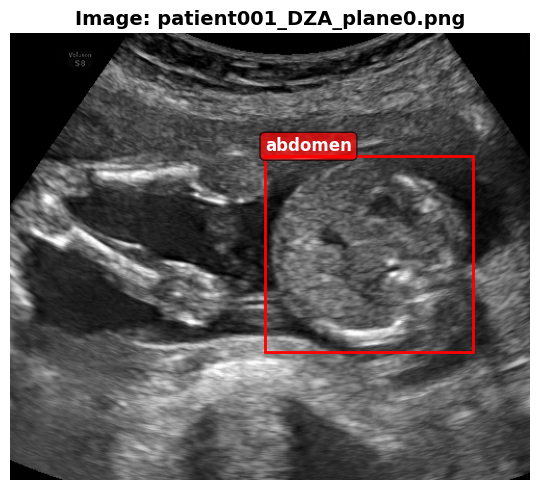

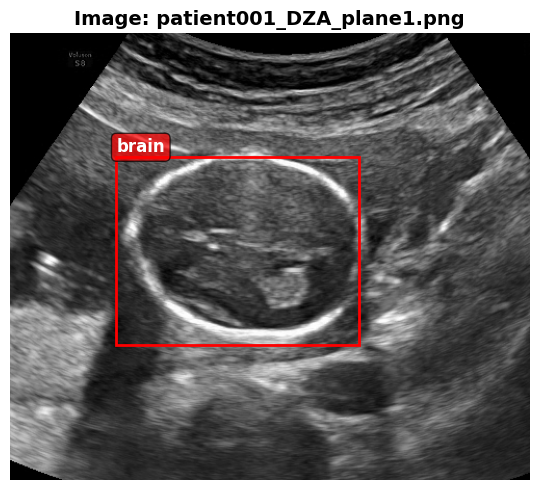

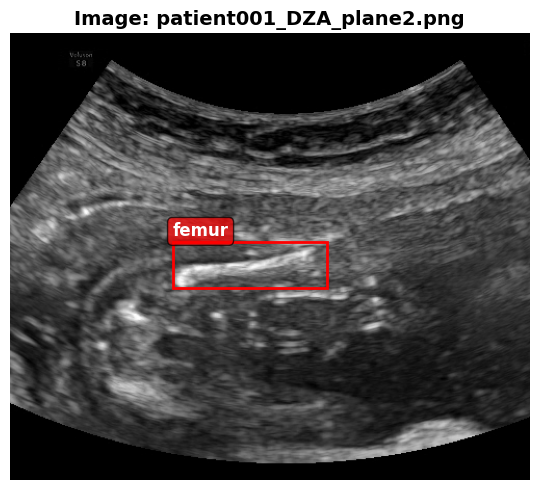

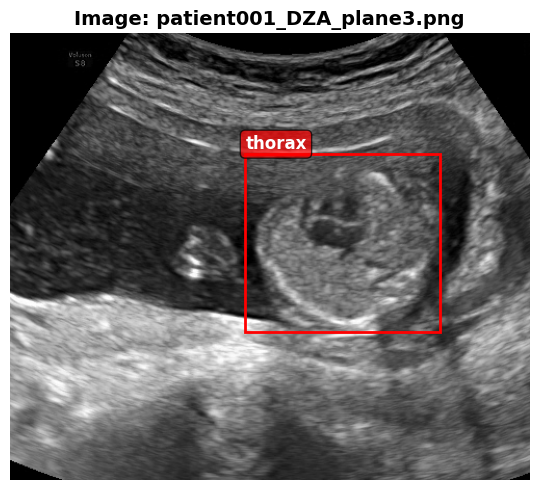

In [ ]:
# lets visualize the 4 different classes in our dataset

visualize_image('/content/tutorial-dataset/images/patient001_DZA_plane0.png', annotations)


visualize_image('/content/tutorial-dataset/images/patient001_DZA_plane1.png', annotations)


visualize_image('/content/tutorial-dataset/images/patient001_DZA_plane2.png', annotations)


visualize_image('/content/tutorial-dataset/images/patient001_DZA_plane3.png', annotations)



## Preprocess data for hugging face models

Before using hugging face models, the image data needs to be prepared in a way that the model can understand. This is done by creating dataset classes and data loaders. *Dataset Classes* are containers that hold your data (images + annotations) in a structured way that machine learning models can understand. *DataLoaders* are workers that fetch data from your dataset in small batches and feed it to the model during training.

Doing this helps the model train faster on multiple images at once and loads only what fits in memory.

### config setup

In [ ]:

# Configure model setup for  ultrasound detection
def configure_model_for_medical_use():
    """
    Show how to adapt the model for medical imaging
    """
    print("⚙️ Model Configuration for Medical Use:")
    print("=" * 42)

    # Define medical classes
    medical_classes = {
        0: 'background',  # No object
        1: 'abdomen',
        2: 'thorax',
        3: 'brain',
        4: 'femur'
    }

    print("🏷️  Medical Class Mapping:")
    for class_id, class_name in medical_classes.items():
        print(f"   {class_id}: {class_name}")

    # Configuration parameters
    config_params = {
        'num_classes': len(medical_classes),
        'confidence_threshold': 0.7,  # Higher threshold for medical use
        'max_detections': 2,          # Max objects per image
        "model_type": "detr",
        "model_name": "facebook/detr-resnet-50",
        'image_size': (512, 512),      # Standard image size required for detr
    }

    print(f"\n⚙️ Configuration Parameters:")
    for param, value in config_params.items():
        print(f"   {param}: {value}")

    return medical_classes, config_params

# Configure for medical use
medical_classes, config = configure_model_for_medical_use()


⚙️ Model Configuration for Medical Use:
🏷️  Medical Class Mapping:
   0: background
   1: abdomen
   2: thorax
   3: brain
   4: femur

⚙️ Configuration Parameters:
   num_classes: 5
   confidence_threshold: 0.7
   max_detections: 2
   model_type: detr
   model_name: facebook/detr-resnet-50
   image_size: (512, 512)


In [ ]:
config.keys()

dict_keys(['num_classes', 'confidence_threshold', 'max_detections', 'model_type', 'model_name', 'image_size'])

In [ ]:
# create dataset class (to wrap up the data loading and preprocessing logic)
class ROIDataset(Dataset):
    def __init__(self, img_dir, json_file, config, train=False):
        super().__init__()
        self.img_dir = img_dir
        self.image_size = tuple(config['image_size'])
        self.train_status = train
        self.model_type = config['model_type']

        with open(json_file, 'r') as f:
            self.annotations = json.load(f)


    def scale_bbox(self, bbox,orig_size, new_size):
        """
        Scales bounding box coordinates based on image size
        """
        x_min, y_min, x_max, y_max = bbox
        orig_w, orig_h = orig_size
        new_w, new_h = new_size

        w_scale= new_w / orig_w
        h_scale = new_h / orig_h

        x_min = x_min * w_scale
        x_max = x_max * w_scale
        y_min = y_min * h_scale
        y_max = y_max * h_scale
        return torch.tensor([x_min, y_min, x_max, y_max], dtype=torch.float32)

    def convert_bbox_format(self, bbox, img_width=None, img_height=None, original_format="corners"):
        """
        Converts bounding box to the required format based on the model type
        """
        x_min,y_min, x_max, y_max = bbox

        if self.model_type == 'yolo':
            # Convert to YOLO format [x_center, y_center, width, height]
            width = x_max - x_min
            height = y_max - y_min
            x_center = x_min + width/2
            y_center = y_min + height/2

            # Normalize
            x_center /= img_width
            y_center /= img_height
            width /= img_width
            height /= img_height

            return [x_center, y_center, width, height]

        elif self.model_type == 'detr':
            # Convert to normalized corners format
            return [x_min/img_width, y_min/img_height,
                    x_max/img_width, y_max/img_height]

        elif self.model_type == 'faster_rcnn':
            # Keep as absolute coordinates
            return [x_min, y_min, x_max, y_max]


    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        img_ann = self.annotations[idx]
        img_path = os.path.join(self.img_dir, img_ann['image_filename'])

        # Read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB format

        # convert string labels to integer IDs
        labels = torch.tensor([LABEL_MAP[img_ann['label']]] , dtype=torch.int64)
        boxes = torch.tensor(img_ann['bbox'], dtype=torch.float32)
        scaled_boxes = self.scale_bbox(boxes,orig_size=img.shape[:2],new_size=self.image_size)
        if scaled_boxes.ndim == 1:
            scaled_boxes = scaled_boxes[np.newaxis, :]

        target = {'boxes': scaled_boxes, 'labels': labels}

        return img, target

In [ ]:
# setup dataset
img_dir = "/content/tutorial-dataset/images"
annotations_file = "/content/tutorial-dataset/algeria_annotations.json"

train_dataset = ROIDataset(
        img_dir=img_dir,
        json_file=annotations_file,
        config=config,
        train=True
    )

In [ ]:
# setup dataloader
from torch.utils.data import DataLoader

def create_data_loader(dataset, batch_size=4, shuffle=True):
    """
    Create data loader for ultrasound images
    """
    print(f"📦 Creating Data Loader:")
    print(f"   Batch size: {batch_size}")
    print(f"   Shuffle: {shuffle}")

    data_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=shuffle,)

    return data_loader

# Configure data loader
train_loader = create_data_loader(train_dataset, batch_size=2)


📦 Creating Data Loader:
   Batch size: 2
   Shuffle: True


# Loading the detection model

We will load the model from hugging face platform:

In [ ]:
# Load pre-trained DETR model for object detection
MODEL_NAME = "facebook/detr-resnet-50"

print(f"📥 Loading model: {MODEL_NAME}")
print("This model uses Detection TRansformer (DETR) architecture...")

try:
    # Load image processor and model
    processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
    model = AutoModelForObjectDetection.from_pretrained(MODEL_NAME)

    print("✅ Model loaded successfully!")
    print(f"📊 Model details:")
    print(f"   Architecture: DETR (DEtection TRansformer)")
    print(f"   Backbone: ResNet-50")
    print(f"   Pre-trained on: COCO dataset")
    print(f"   Output: Object detection with bounding boxes")

    # Model architecture overview
    print(f"\n🏗️  Model Architecture:")
    print(f"   Input size: 512x512 pixels (recommended)")
    print(f"   Transformer layers: 6 encoder + 6 decoder")
    print(f"   Object queries: 100 learnable queries")
    print(f"   Classes: Originally 91 COCO classes")

except Exception as e:
    print(f"❌ Error loading model: {str(e)}")
    print("Note: In a real environment, ensure you have internet connection")

📥 Loading model: facebook/detr-resnet-50
This model uses DEtection TRansformer (DETR) architecture...


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Model loaded successfully!
📊 Model details:
   Architecture: DETR (DEtection TRansformer)
   Backbone: ResNet-50
   Pre-trained on: COCO dataset
   Output: Object detection with bounding boxes

🏗️  Model Architecture:
   Input size: 512x512 pixels (recommended)
   Transformer layers: 6 encoder + 6 decoder
   Object queries: 100 learnable queries
   Classes: Originally 91 COCO classes


# Fine-tuning the model
The model needs to learn how to detect structures on OUR dataset. We do this by "fine-tuning" it on our dataset. This is a transfer learning approach where transfer the knowledge of the model from the coco dataset to our custom medical dataset. This involves re-training the model on our dataset. Because the model has already learned something from the coco datset, it only needs a few passes on our dataset to learn the patterns.


In [ ]:
import torch.nn as nn

def setup_medical_finetuning():
    """
    Setup fine-tuning process for medical object detection
    """
    print("🎓 Fine-tuning Strategy for Medical Imaging:")
    print("=" * 48)


    # Training configuration
    training_config = {
        'learning_rate': 1e-5,     # Lower for fine-tuning
        'batch_size': 2,           # Smaller for medical data
        'epochs': 10,              # More epochs for convergence
        'weight_decay': 1e-4,      # Regularization
        'scheduler': 'cosine',     # Learning rate scheduling
        'augmentation': 'minimal'  # Preserve medical accuracy
    }

    print(f"\n⚙️ Training Configuration:")
    for param, value in training_config.items():
        print(f"   {param}: {value}")

    return training_config

training_config = setup_medical_finetuning()

# Update model for the  number of classes
model.class_labels_classifier = nn.Linear(model.class_labels_classifier.in_features, config['num_classes'])

print(f"✅ Model updated for {config['num_classes']} classes")


🎓 Fine-tuning Strategy for Medical Imaging:

⚙️ Training Configuration:
   learning_rate: 1e-05
   batch_size: 2
   epochs: 10
   weight_decay: 0.0001
   scheduler: cosine
   augmentation: minimal
✅ Model updated for 5 classes


In [ ]:
# setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config['learning_rate'],
    weight_decay=training_config['weight_decay']
)

print(f"🔥 Training on: {device}")

🔥 Training on: cpu


In [ ]:
# train model
from tqdm import tqdm

model.train()

epochs = training_config['epochs']
for epoch in range(epochs):
    total_loss = 0

    print(f"\n🚀 Epoch {epoch+1}/{epochs}")

    for batch_idx, (images, targets) in enumerate(tqdm(train_loader)):
          images = [img.to(device) for img in images]
          targets = [{k: v.to(device) for k, v in t.items()}
                    for t in targets]

          loss_dict = model(images, targets)
          losses = sum(loss for loss in loss_dict.values())

          optimizer.zero_grad()
          losses.backward()
          optimizer.step()

          total_loss += losses.item()


    avg_loss = total_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1} completed - Average Loss: {avg_loss:.4f}")

print("\n🎉 Training completed!")


🚀 Epoch 1/10


  0%|          | 0/8 [00:00<?, ?it/s]


AttributeError: 'str' object has no attribute 'items'